In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated, Literal, NotRequired, Optional
from langchain_openai import ChatOpenAI
from pydantic import BaseModel,Field
from dotenv import load_dotenv
import operator
import json
import os
load_dotenv()

True

In [2]:
llm = ChatOpenAI(
    model="google/gemma-4-31B-it:fastest",
    base_url="https://router.huggingface.co/v1",
    api_key=os.getenv("HF_API_KEY")
)

In [3]:
parser_llm = ChatOpenAI(
    model="google/gemma-4-26B-A4B-it:fastest",
    base_url="https://router.huggingface.co/v1",
    api_key=os.getenv("HF_API_KEY")
)

In [4]:
class NutrientRow(TypedDict):
    per_100g: NotRequired[float]
    per_serving: NotRequired[float]
    unit: str

In [5]:
class NutritionTable(TypedDict):
    energy: NotRequired[NutrientRow]
    protein: NotRequired[NutrientRow]
    carbohydrates: NotRequired[NutrientRow]
    total_sugars: NotRequired[NutrientRow]
    added_sugars: NotRequired[NutrientRow]
    dietary_fiber: NotRequired[NutrientRow]
    total_fat: NotRequired[NutrientRow]
    saturated_fat: NotRequired[NutrientRow]
    trans_fat: NotRequired[NutrientRow]
    sodium: NotRequired[NutrientRow]

In [6]:
class ServingInfo(TypedDict):
    serving_size: float
    serving_unit: str

In [7]:
class EvaluationInput(TypedDict):
    nutrition_table: NutritionTable

    serving_info: ServingInfo

    ingredients: list[str]

    ins_codes: list[str]

In [8]:
class NutritionState(TypedDict):
    raw_ocr_text: str
    parsed_label: EvaluationInput | None
    nutrient_analysis: dict | None
    ingredient_analysis: dict | None
    ins_analysis: dict | None
    allergen_analysis: dict | None
    processing_analysis: dict | None
    final_report: dict | None

In [9]:
class NutritionParser(BaseModel):
    parsed_label: EvaluationInput = Field(description="The structured representation of the nutrition label, including the nutrition table, serving information, list of ingredients, and list of INS codes.")

In [10]:
structured_parser_llm = parser_llm.with_structured_output(NutritionParser)

In [11]:
def parse_nutrition_label(state: NutritionState):
    """Parses the raw OCR text of a nutrition label and returns a structured representation of the nutrition information."""
    raw_text = state["raw_ocr_text"]
    
    messages = [
        {"role": "system", "content": "You are a helpful assistant for parsing nutrition labels. You will be given the raw OCR text extracted from a nutrition label, and your task is to parse this text and extract the relevant information into a structured format. Return the parsed nutrition label with nutrition_table, serving_info, ingredients list, and INS codes list."},
        {"role": "user", "content": f"Here is the raw OCR text from the nutrition label:\n\n{raw_text}\n\nPlease parse this information and provide a structured representation of the nutrition label, including the nutrition table, serving information, list of ingredients, and list of INS codes."}
    ]
    
    result = structured_parser_llm.invoke(messages)
    # Handle both dict and object returns
    if isinstance(result, dict):
        parsed_label = result.get("parsed_label", result)
    else:
        parsed_label = result.parsed_label
    
    result = {
        "nutrition_table": parsed_label["nutrition_table"],
        "serving_info": parsed_label["serving_info"],
        "ingredients": parsed_label["ingredients"],
        "ins_codes": parsed_label["ins_codes"]
    }
    
    return {
        "parsed_label": result
    }

In [12]:
# # Test parse function (optional - run this to test the parser alone)
# test_state = {
#     "raw_ocr_text": "IngredientsPotato (88%), edible vegetable oil (palmolein), edible common salt, spices & condiments 0.5% (cumin, chilli, parsley, ginger, cinnamon, black pepper, dry mango), dehydrated vegetable powder (onion, garlic), sugar, maltodextrin, flavour enhancer (INS 627, INS 631), acidity regulator (INS 296, INS 330), anticaking agent (INS 551), natural & nature identical flavouring substances (chaat).  Nutritional Information (per 100g)NutrientAmountEnergy545 kcalProtein7.4gCarbohydrates53.5gTotal Sugars3.0gAdded Sugars2.2gTotal Fat32.2gSaturated Fat15.3gTrans Fat0.1gCholesterol<1mgSodium982mg",
#     "parsed_label": None,
#     "nutrient_analysis": None,
#     "ingredient_analysis": None,
#     "ins_analysis": None,
#     "allergen_analysis": None,
#     "processing_analysis": None,
#     "final_report": None
# }

# result = parse_nutrition_label(test_state)
# print("Parsed label:", result["parsed_label"])

In [13]:
class NutrientAnalysis(BaseModel):
    nutrient: str
    value_per_100g: float | None
    value_per_serving: float | None
    unit: str
    scale_breakpoints: list[float]
    classification: str
    score: float
    explanation: str   

In [14]:
class NutrientAnalysisOutput(BaseModel):
    nutrients: list[NutrientAnalysis] = Field(description="A list of analyses for each nutrient, including the nutrient name, values per 100g and per serving, unit of measurement, scale breakpoints for classification, the classification itself (e.g., low/medium/high), a numerical score, and an explanation of the classification.")

In [15]:
NUTRIENT_SCALES = {
    "protein": [0, 3, 6, 12, 20, 75],
    "fiber": [0, 1.5, 3, 6, 9, 30],
    "sugar": [0, 2.5, 5, 10, 15, 50],
    "sodium": [0, 120, 300, 600, 1200, 3000],
    "saturated_fat": [0, 1.5, 3, 5, 10, 25]
}

In [16]:
nutrient_analysis_llm = ChatOpenAI(
    model="google/gemma-4-26B-A4B-it:fastest",
    base_url="https://router.huggingface.co/v1",
    api_key=os.getenv("HF_API_KEY")
)

In [17]:
nutrient_analysis_structured = nutrient_analysis_llm.with_structured_output(NutrientAnalysisOutput)

In [18]:
def nutrient_analysis(state: NutritionState):
    """Nutrition Scientist Analyzes the nutritional content of a food product based on its nutrition table and serving information, classifying each nutrient according to predefined scales and providing explanations for the classifications."""
    parsed = state["parsed_label"]
    nutrition_table = parsed["nutrition_table"]
    serving_info = parsed["serving_info"]
    
    messages = [
        {"role": "system", "content": "You are a nutrition scientist analyzing the nutritional content of a food product based on its nutrition table and serving information. Your task is to classify each nutrient according to predefined scales and provide explanations for the classifications."},
        {"role": "user", "content": f"""Here is the nutrition table for the food product:\n\n{nutrition_table}\n\nAnd here is the serving information:\n\n{serving_info}\n\nPlease analyze the nutritional content of this food product, classify each nutrient according to the following scales, and provide explanations for your classifications:\n\n{NUTRIENT_SCALES}.
        For each nutrient:
        - Identify the nutrient name (e.g., protein, fiber, sugar, sodium, saturated fat).
        - Determine Score 0-5
        - Explain Briefly explain the reasoning behind the classification, referencing the specific values from the nutrition table and how they compare to the scale breakpoints.
        
        Note: Don't invent values that are not present in the nutrition table. If a nutrient is missing, classify it as "unknown" and explain that the information is not available.
        - Don't invent scale breakpoints. Use the ones provided in the system prompt. If a nutrient is not listed in the scales, classify it as "not evaluated" and explain that there are no predefined criteria for that nutrient.
        """}
    ]
    result = nutrient_analysis_structured.invoke(messages)
    # Handle both dict and object returns
    if isinstance(result, dict):
        analysis = result.get("nutrients", result)
    else:
        analysis = result.nutrients
    
    # state["nutrient_analysis"] = analysis
    return {
        "nutrient_analysis": analysis
    }

In [19]:
class IngredientFinding(BaseModel):
    ingredient: str
    category: str
    impact: str
    reason: str

In [20]:
class IngredientAnalysis(BaseModel):
    ingredient_quality_score: float = Field(description="A numerical score representing the overall quality of the ingredient, based on factors such as nutritional value, presence of additives or preservatives, and potential health impacts. The score should be on a scale from 0 to 5, where higher scores indicate better quality.")
    positives: list[IngredientFinding] = Field(description="A list of positive findings about the ingredient, including the specific aspect of the ingredient that is beneficial, the category it falls under (e.g., nutritional value, natural origin), the impact it has on health (e.g., supports heart health, rich in vitamins), and a brief reason explaining why this aspect is considered positive.")
    negatives: list[IngredientFinding] = Field(description="A list of negative findings about the ingredient, including the specific aspect of the ingredient that is concerning, the category it falls under (e.g., presence of additives, high in unhealthy fats), the impact it has on health (e.g., may contribute to heart disease, linked to allergies), and a brief reason explaining why this aspect is considered negative.")
    concerns: list[IngredientFinding] = Field(description="A list of concerns about the ingredient, including the specific aspect of the ingredient that is concerning, the category it falls under (e.g., potential allergens, controversial additives), the impact it may have on health (e.g., may trigger allergies, linked to health issues), and a brief reason explaining why this aspect is considered a concern.")
    processing_indicator: str = Field(description="An indicator of the level of processing of the ingredient, classified as 'unprocessed', 'minimally processed', 'processed', or 'ultra-processed', based on the nature of the ingredient and the extent of processing it has undergone.")
    summary: str = Field(description="A brief summary of the overall quality of the ingredient, taking into account the positives, negatives, concerns, and processing level. This summary should provide a clear and concise evaluation of the ingredient's healthfulness and suitability for consumption.")

In [21]:
ingredient_analysis_llm = ChatOpenAI(
    model="google/gemma-4-26B-A4B-it:fastest",
    base_url="https://router.huggingface.co/v1",
    api_key=os.getenv("HF_API_KEY")
)

In [22]:
ingredient_analysis_structured = ingredient_analysis_llm.with_structured_output(IngredientAnalysis)

In [23]:
def ingredient_analysis(state: NutritionState):
    """Ingredient Expert evaluates the quality of all ingredients in the product."""
    parsed = state["parsed_label"]
    ingredients = parsed["ingredients"]
    
    all_analyses = {}
    
    for ingredient in ingredients:
        messages = [
            {"role": "system", "content": "You are an ingredient expert evaluating the quality of a specific ingredient. Your task is to provide a comprehensive analysis of the ingredient, including positive aspects, negative aspects, concerns, and an overall quality score. Additionally, you should classify the level of processing of the ingredient."},
            {"role": "user", "content": f"""Please analyze the following ingredient: {ingredient}\n\nIn your analysis, please include the following:\n\n1. Ingredient Quality Score: Provide a numerical score from 0 to 5 representing the overall quality of the ingredient, based on factors such as nutritional value, presence of additives or preservatives, and potential health impacts. Higher scores indicate better quality.\n\n2. Positives: List any positive findings about the ingredient, including specific beneficial aspects (e.g., supports heart health, rich in vitamins), the category they fall under (e.g., nutritional value, natural origin), and a brief reason explaining why these aspects are considered positive.\n\n3. Negatives: List any negative findings about the ingredient, including specific concerning aspects (e.g., may contribute to heart disease, linked to allergies), the category they fall under (e.g., presence of additives, high in unhealthy fats), and a brief reason explaining why these aspects are considered negative.\n\n4. Concerns: List any concerns about the ingredient that may not be strictly negative but warrant caution (e.g., potential allergens, controversial additives), including the category they fall under and a brief reason explaining why these concerns are relevant.\n\n5. Processing Indicator: Classify the level of processing of the ingredient as 'unprocessed', 'minimally processed', 'processed', or 'ultra-processed', based on the nature of the ingredient and the extent of processing it has undergone.\n\n6. Summary: Provide a brief summary that synthesizes your analysis into an overall evaluation of the ingredient's healthfulness and suitability for consumption.
    
        Score Rules:
        5 = Excellent quality ingredient with high nutritional value, no additives or preservatives, and significant health benefits.
        4 = mostly whole food ingredient with good nutritional value and minimal additives, but may have some minor concerns or be slightly processed.
        3 = ingredient with moderate nutritional value or some additives/preservatives, but not excessively
        2 = ingredient with low nutritional value, presence of additives/preservatives, or potential health concerns.
        1 = ingredient with very low nutritional value, significant presence of additives/preservatives, or known health risks.
        0 = ingredient with no nutritional value, high levels of harmful additives/preservatives, or severe health risks.
        """}
        ]
        result = ingredient_analysis_structured.invoke(messages)
        # Handle both dict and object returns
        if isinstance(result, dict):
            all_analyses[ingredient] = result
        else:
            all_analyses[ingredient] = result.model_dump()
    
    # state["ingredient_analysis"] = all_analyses
    return {
        "ingredient_analysis": all_analyses
    }

In [24]:
import json
import os
from pathlib import Path
from typing import Optional


In [25]:

def json_output_instruction(model_class):
    """Generate a JSON schema instruction string from a Pydantic model"""
    schema = model_class.model_json_schema()
    return f"\nOutput Format: {json.dumps(schema, indent=2)}"


In [26]:
# Pydantic models for INS data based on the schema
class INSApprovals(BaseModel):
    """Food additive approval status by region"""
    A: bool = Field(description="Approved in Australia/NZ")
    E: bool = Field(description="Approved in Europe")
    U: bool = Field(description="Approved in United States")

class INSAdditive(BaseModel):
    """Complete INS additive information from dataset"""
    id: str = Field(description="Unique identifier (e.g., INS-650)")
    ins_code: str = Field(description="INS code (e.g., 650)")
    name: str = Field(description="Name of the food additive")
    type: str = Field(description="Type/category of additive (e.g., flavour enhancer, colour)")
    approvals: INSApprovals = Field(description="Approval status by region")
    text: str = Field(description="Full text description of the additive")

class INSAnalysisFinding(BaseModel):
    """Individual finding about an INS additive in food"""
    ins_code: str = Field(description="The INS code")
    additive_name: str = Field(description="Name of the additive")
    category: str = Field(description="Category/type of additive")
    safety_level: str = Field(description="Safety classification: 'approved', 'restricted', 'controversial', or 'unknown'")
    health_impact: str = Field(description="Potential health impact description")
    approval_status: str = Field(description="Approval regions - which regions approve this additive")
    recommendation: str = Field(description="Recommendation: 'safe', 'caution', 'avoid', or 'limited'")
    reason: str = Field(description="Detailed reasoning for the classification")

class INSAnalysisOutput(BaseModel):
    """Complete INS analysis for all additives in a product"""
    total_additives: int = Field(description="Total number of INS additives found")
    findings: list[INSAnalysisFinding] = Field(description="Analysis findings for each INS additive")
    overall_safety_score: float = Field(description="Overall safety score from 0-5, where 5 is safest")
    safety_summary: str = Field(description="Summary of overall additive safety")
    recommendations: list[str] = Field(description="General recommendations based on the additive analysis")


In [27]:
# INS Dataset Loader and Utilities
class INSDataset:
    """Manages loading and searching INS additive data from the dataset directory"""
    
    def __init__(self, dataset_dir: str = "dataset"):
        self.dataset_dir = Path(dataset_dir)
        self.additives: dict[str, INSAdditive] = {}
        self.synonyms: dict[str, str] = {}
        self.load_data()
    
    def load_data(self):
        """Load INS additives from JSONL file and synonyms from JSON file"""
        # Load JSONL dataset
        jsonl_path = self.dataset_dir / "INS_agent_dataset.jsonl"
        if jsonl_path.exists():
            with open(jsonl_path, 'r', encoding='utf-8') as f:
                for line in f:
                    if line.strip():
                        data = json.loads(line)
                        additive = INSAdditive(**data)
                        self.additives[additive.ins_code] = additive
            print(f"✓ Loaded {len(self.additives)} additives from dataset")
        else:
            print(f"⚠ Warning: Dataset file not found at {jsonl_path}")
        
        # Load synonyms
        synonyms_path = self.dataset_dir / "INS_synonyms.json"
        if synonyms_path.exists():
            with open(synonyms_path, 'r', encoding='utf-8') as f:
                self.synonyms = json.load(f)
            print(f"✓ Loaded {len(self.synonyms)} synonym mappings")
        else:
            print(f"⚠ Warning: Synonyms file not found at {synonyms_path}")
    
    def lookup_by_code(self, ins_code: str) -> Optional[INSAdditive]:
        """Look up an additive by its INS code"""
        # Normalize the code (remove leading zeros, handle formatting)
        code = str(ins_code).strip().lower()
        
        # Direct lookup
        if code in self.additives:
            return self.additives[code]
        
        # Try with 'INS' prefix
        if f"INS {code}" in self.additives:
            return self.additives[f"INS {code}"]
        
        return None
    
    def lookup_by_name(self, name: str) -> Optional[INSAdditive]:
        """Look up an additive by name (with synonym resolution)"""
        name_lower = name.lower().strip()
        
        # Check synonyms first
        if name_lower in self.synonyms:
            code = self.synonyms[name_lower]
            return self.lookup_by_code(code)
        
        # Direct name search (case-insensitive)
        for additive in self.additives.values():
            if additive.name.lower() == name_lower:
                return additive
        
        return None
    
    def search(self, query: str) -> list[INSAdditive]:
        """Search for additives by code or name (partial match)"""
        results = []
        query_lower = query.lower().strip()
        
        # Try direct lookup first
        direct = self.lookup_by_code(query) or self.lookup_by_name(query)
        if direct:
            results.append(direct)
        
        # Partial search in names and types
        for additive in self.additives.values():
            if query_lower in additive.name.lower() or query_lower in additive.type.lower():
                if additive not in results:
                    results.append(additive)
        
        return results[:10]  # Return top 10 results

# Initialize the dataset
ins_dataset = INSDataset()


✓ Loaded 436 additives from dataset
✓ Loaded 520 synonym mappings


In [28]:
def lookup_food_additive(query: str) -> dict:
    """Lookup food additive by INS code or additive name (matches the function schema)"""
    results = ins_dataset.search(query)
    
    if not results:
        return {
            "found": False,
            "query": query,
            "message": "No additive found matching the query"
        }
    
    additives_data = []
    for additive in results:
        additives_data.append({
            "id": additive.id,
            "ins_code": additive.ins_code,
            "name": additive.name,
            "type": additive.type,
            "approvals": additive.approvals.model_dump(),
            "text": additive.text
        })
    
    return {
        "found": True,
        "query": query,
        "results": additives_data,
        "count": len(additives_data)
    }

In [29]:
# Create LLM for INS analysis
ins_analysis_llm = llm.with_structured_output(INSAnalysisOutput)

def ins_analysis(state: NutritionState):
    """
    Analyzes a list of INS codes found in a food product by:
    1. Looking up each code in the dataset
    2. Determining safety level based on approval status
    3. Providing detailed findings and recommendations
    4. Calculating overall safety score
    """
    parsed = state["parsed_label"]
    ins_codes = parsed["ins_codes"]
    
    if not ins_codes:
        state["ins_analysis"] = {
            "total_additives": 0,
            "findings": [],
            "overall_safety_score": 5.0,
            "safety_summary": "No food additives found in this product.",
            "recommendations": ["This product appears to be additive-free."]
        }
        return {
            "ins_analysis": state["ins_analysis"]
        }
    
    # Look up all additives using the dataset
    findings = []
    total_approved = 0
    total_controversial = 0
    additive_details = []
    
    for code in ins_codes:
        additive = ins_dataset.lookup_by_code(code)
        
        if additive:
            # Determine safety level based on approval status
            approved_regions = sum([additive.approvals.A, additive.approvals.E, additive.approvals.U])
            
            if approved_regions == 3:
                safety_level = "approved"
                recommendation = "safe"
                total_approved += 1
            elif approved_regions == 2:
                safety_level = "restricted"
                recommendation = "caution"
            elif approved_regions == 1:
                safety_level = "controversial"
                recommendation = "limited"
                total_controversial += 1
            else:
                safety_level = "unknown"
                recommendation = "avoid"
                total_controversial += 1
            
            # Create approval status string
            approval_regions = []
            if additive.approvals.A:
                approval_regions.append("Australia/NZ")
            if additive.approvals.E:
                approval_regions.append("Europe")
            if additive.approvals.U:
                approval_regions.append("USA")
            approval_status = ", ".join(approval_regions) if approval_regions else "Not approved in major regions"
            
            # Create finding
            finding = INSAnalysisFinding(
                ins_code=additive.ins_code,
                additive_name=additive.name,
                category=additive.type,
                safety_level=safety_level,
                health_impact=f"Categorized as {additive.type}. {additive.text}",
                approval_status=approval_status,
                recommendation=recommendation,
                reason=f"{additive.name} is approved in {approved_regions}/3 major regions ({approval_status}). Classified as {safety_level}."
            )
            findings.append(finding)
            additive_details.append({
                "code": additive.ins_code,
                "name": additive.name,
                "safety": safety_level
            })
        else:
            # Additive not found in database
            finding = INSAnalysisFinding(
                ins_code=code,
                additive_name=f"Unknown (INS {code})",
                category="Unknown",
                safety_level="unknown",
                health_impact="Additive not found in database",
                approval_status="Unknown",
                recommendation="caution",
                reason=f"INS code {code} not found in the additive database. Caution advised."
            )
            findings.append(finding)
            total_controversial += 1
    
    # Calculate overall safety score
    # Base score is 5.0, subtract for controversial additives
    safety_score = 5.0 - (total_controversial * 0.5)
    safety_score = max(0.0, min(5.0, safety_score))
    
    # Generate summary
    if safety_score >= 4.5:
        safety_summary = f"This product contains {len(findings)} well-established food additives that are approved in multiple regions. Overall safety profile is excellent."
    elif safety_score >= 4.0:
        safety_summary = f"This product contains {len(findings)} food additives, all approved in major regions. Overall safety profile is good."
    elif safety_score >= 3.0:
        safety_summary = f"This product contains {len(findings)} additives with mostly approved status. {total_controversial} additive(s) have limited or uncertain approval. Generally acceptable."
    elif safety_score >= 2.0:
        safety_summary = f"This product contains {len(findings)} additives with {total_controversial} controversial or unapproved additive(s). Caution recommended."
    else:
        safety_summary = f"This product contains {len(findings)} additives with significant approval concerns. Strong caution advised."
    
    # Generate recommendations
    recommendations = []
    if total_approved == len(findings):
        recommendations.append("✓ All additives are universally approved - safe for consumption")
    if total_controversial > 0:
        recommendations.append(f"⚠ {total_controversial} additive(s) have limited approval - consider alternatives")
    if len(findings) > 5:
        recommendations.append("⚠ This product contains many additives - consider products with fewer additives")
    
    recommendations.append(f"Overall Safety Score: {safety_score:.1f}/5")
    
    # Update state and return
    result = {
        "total_additives": len(findings),
        "findings": [finding.model_dump() for finding in findings],
        "overall_safety_score": safety_score,
        "safety_summary": safety_summary,
        "recommendations": recommendations
    }
    return {
        "ins_analysis": result
    }

In [30]:
class AllergenFinding(BaseModel):
    allergen: str = Field(
        description="Standard allergen name"
    )
    source: str = Field(
        description="Ingredient that triggered detection"
    )
    severity: str = Field(
        description="low, moderate, high"
    )
    detected: bool = True

In [31]:
class AllergenAnalysis(BaseModel):
    allergens_detected: list[AllergenFinding]

    allergen_free_claims: list[str] = Field(
        description="Allergens not detected"
    )

    summary: str

In [32]:
allergen_llm = ChatOpenAI(
    model="google/gemma-4-26B-A4B-it:fastest",
    base_url="https://router.huggingface.co/v1",
    api_key=os.getenv("HF_API_KEY")
)

In [33]:
allergen_analysis_llm = allergen_llm.with_structured_output(AllergenAnalysis)

In [34]:
def allergen_analysis(state: NutritionState):
    """Allergen Expert analyzes a list of ingredients to detect potential allergens and provide a summary of allergen risks."""
    parsed = state["parsed_label"]
    ingredients = parsed["ingredients"]
    
    messages = [
        {"role": "system", "content": "You are an allergen expert analyzing a list of ingredients to identify potential allergens. Your task is to detect any common allergens present in the ingredient list, assess their severity, and provide a summary of allergen risks."},
        {"role": "user", "content": f"""Please analyze the following list of ingredients for potential allergens: {ingredients}\n\nIn your analysis, please include the following:\n\n1. Allergens Detected: For each allergen detected, provide the standard allergen name, the specific ingredient that triggered the detection, and an assessment of the severity (low, moderate, high) based on common allergen classifications.\n\n2. Allergen-Free Claims: List any common allergens that were not detected in the ingredient list, which could be relevant for consumers with specific allergies.\n\n3. Summary: Provide a brief summary that synthesizes your findings into an overall assessment of the allergen risks associated with this product. This summary should help consumers understand the potential allergen concerns and make informed decisions about consumption.
    
    Common Allergens to Check For:
    - Milk
    - Eggs
    - Fish
    - Shellfish
    - Tree Nuts (e.g., almonds, walnuts)
    - Peanuts
    - Wheat
    - Soy
    - Sesame
    
    Severity Assessment Guidelines:
    - Low: Allergen is present in trace amounts or is unlikely to cause a reaction in most individuals.
    - Moderate: Allergen is present in measurable amounts and may cause a reaction in some individuals.
    - High: Allergen is present in significant amounts and is likely to cause a reaction in most individuals.
    """}
    ]
    
    result = allergen_analysis_llm.invoke(messages)
    # Handle both dict and object returns
    if isinstance(result, dict):
        analysis = result
    else:
        analysis = result.model_dump()
    
    return {
        "allergen_analysis": analysis
    }

In [35]:
class ProcessingIndicator(BaseModel):
    ingredient: str = Field(description="The specific ingredient being analyzed.")
    reason: str = Field(description="A brief explanation of why this ingredient is classified at this level of processing.")
    impact: str = Field(
        description="positive, negative, or neutral impact on health based on the processing level and ingredient characteristics."
    )

In [36]:
class NOVAAnalysis(BaseModel):
    nova_group: int = Field(
        description="1-4"
    )
    classification: str = Field(
        description="""
        Unprocessed,
        Processed Culinary Ingredient,
        Processed Food,
        Ultra Processed Food
        """
    )
    processing_score: float = Field(
        description="0-5"
    )
    indicators: list[ProcessingIndicator]
    summary: str

In [37]:
nova_llm = ChatOpenAI(
    model="google/gemma-4-26B-A4B-it:fastest",
    base_url="https://router.huggingface.co/v1",
    api_key=os.getenv("HF_API_KEY")
)

In [38]:
nova_analysis_llm = nova_llm.with_structured_output(NOVAAnalysis)

In [39]:
def nova_analysis(state: NutritionState) -> dict:
    """NOVA Expert classifies all ingredients according to the NOVA processing classification system."""
    parsed = state["parsed_label"]
    ingredients = parsed["ingredients"]
    
    all_analyses = {}
    
    for ingredient in ingredients:
        messages = [
            {"role": "system", "content": "You are a NOVA expert analyzing a specific ingredient to classify it according to the NOVA processing classification system. Your task is to determine the appropriate NOVA group for the ingredient, provide a detailed explanation of the classification, and identify specific indicators that justify the processing level assigned."},
            {"role": "user", "content": f"""Please analyze the following ingredient: {ingredient}\n\nIn your analysis, please include the following:\n\n1. NOVA Group Classification: Assign the ingredient to one of the four NOVA groups (1-4) based on its level of processing. Provide a clear justification for why this ingredient belongs to the assigned group.\n\n2. Classification Description: Provide a brief description of what the assigned NOVA group represents in terms of processing and typical characteristics of ingredients in that group.\n\n3. Processing Score: Assign a numerical score from 0 to 5 representing the degree of processing, where 0 indicates no processing and 5 indicates extreme processing. Justify your score based on the characteristics of the ingredient and its processing level.\n\n4. Indicators: List specific indicators that support your classification, including any positive aspects (e.g., natural origin, minimal processing), negative aspects (e.g., presence of additives, extensive processing), or neutral aspects (e.g., common culinary use) that are relevant to the ingredient's classification. For each indicator, specify whether it has a positive, negative, or neutral impact on health and provide a brief explanation."""}
        ]
        
        result = nova_analysis_llm.invoke(messages)
        # Handle both dict and object returns    
        if isinstance(result, dict):
            all_analyses[ingredient] = result
        else:
            all_analyses[ingredient] = result.model_dump()
    
    return {
        "processing_analysis": all_analyses
    }

In [40]:
class FinalNutritionScientistInput(BaseModel):
    nutrient_analysis: NutrientAnalysisOutput
    ingredient_analysis: IngredientAnalysis
    ins_analysis: INSAnalysisOutput
    allergen_analysis: AllergenAnalysis
    nova_analysis: NOVAAnalysis

In [41]:
class ProductRating(BaseModel):
    score: float = Field(
        description="Overall score from 0-5"
    )
    rating_label: str = Field(
        description="""
        Excellent
        Good
        Average
        Poor
        Avoid
        """
    )

In [42]:
class Insight(BaseModel):
    title: str
    explanation: str

In [43]:
class ConsumptionRecommendation(BaseModel):
    recommendation: str

    frequency: str = Field(
        description="""
        Daily
        Frequent
        Occasional
        Rare
        Avoid
        """
    )

    explanation: str

In [44]:
class FinalNutritionScientistOutput(BaseModel):
    overall_rating: ProductRating
    consumption_recommendation: ConsumptionRecommendation
    positives: list[Insight]
    concerns: list[Insight]
    executive_summary: str
    key_warnings: list[str]
    suitable_for: list[str]
    not_suitable_for: list[str]
    score_breakdown: dict[str, float]

In [45]:
def final_analysis(state: NutritionState):
    """Final Nutrition Scientist synthesizes all analyses into a comprehensive evaluation of the food product."""
    # Get raw analysis data from state (they're already dicts, not Pydantic objects to wrap)
    nutrient_data = state.get("nutrient_analysis", [])
    ingredient_data = state.get("ingredient_analysis", {})
    ins_data = state.get("ins_analysis", {})
    allergen_data = state.get("allergen_analysis", {})
    nova_data = state.get("processing_analysis", {})
    
    # Format the data for the LLM message
    analysis_summary = f"""
    NUTRIENT ANALYSIS:
    {nutrient_data}
    
    INGREDIENT ANALYSIS (per ingredient):
    {ingredient_data}
    
    INS ADDITIVE ANALYSIS:
    {ins_data}
    
    ALLERGEN ANALYSIS:
    {allergen_data}
    
    NOVA PROCESSING ANALYSIS (per ingredient):
    {nova_data}
    """
    
    messages = [
        {"role": "system", "content": "You are a final nutrition scientist tasked with synthesizing various analyses of a food product into a comprehensive evaluation. You will be provided with detailed analyses of the product's nutrient content, ingredient quality, food additives, allergen risks, and processing level. Your task is to integrate this information to provide an overall rating for the product, a consumption recommendation, and detailed insights into its positives and concerns."},
        {"role": "user", "content": f"""Please analyze the following analyses of a food product:\n\n{analysis_summary}\n\nBased on this information, please provide the following outputs:\n\n1. Overall Rating: Assign an overall score from 0 to 5 for the product, along with a corresponding rating label (Excellent, Good, Average, Poor, Avoid). Justify your rating based on the combined findings from all analyses.\n\n2. Consumption Recommendation: Provide a recommendation for how frequently this product should be consumed (Daily, Frequent, Occasional, Rare, Avoid) along with an explanation for this recommendation based on the health impacts identified in the analyses.\n\n3. Positives: List key positive insights about the product that contribute to its nutritional value or healthfulness. For each positive insight, provide a title and a brief explanation.\n\n4. Concerns: List key concerns about the product that may impact its healthfulness or suitability for certain consumers. For each concern, provide a title and a brief explanation.\n\n5. Executive Summary: Provide a concise summary that synthesizes all findings into an overall assessment of the product's nutritional profile and health implications.\n\n6. Key Warnings: Highlight any critical warnings that consumers should be aware of when considering this product.\n\n7. Suitable For: Identify specific groups of consumers for whom this product may be particularly suitable based on its nutritional profile (e.g., athletes, individuals with specific dietary needs).\n\n8. Not Suitable For: Identify specific groups of consumers who should avoid or limit consumption of this product based on potential health risks (e.g., individuals with allergies, those with certain medical conditions).\n\n9. Score Breakdown: Provide a breakdown of how different aspects of the analyses contributed to the overall score, with specific scores for each aspect (0-5 scale for allergens, additives, processing, ingredients, and nutrients)."""}
    ]
    
    result = llm.invoke(messages)
    
    # Handle both dict and object returns
    if isinstance(result, dict):
        final_report = result
    else:
        final_report = result.model_dump() if hasattr(result, 'model_dump') else str(result)
    
    return {
        "final_report": final_report
    }

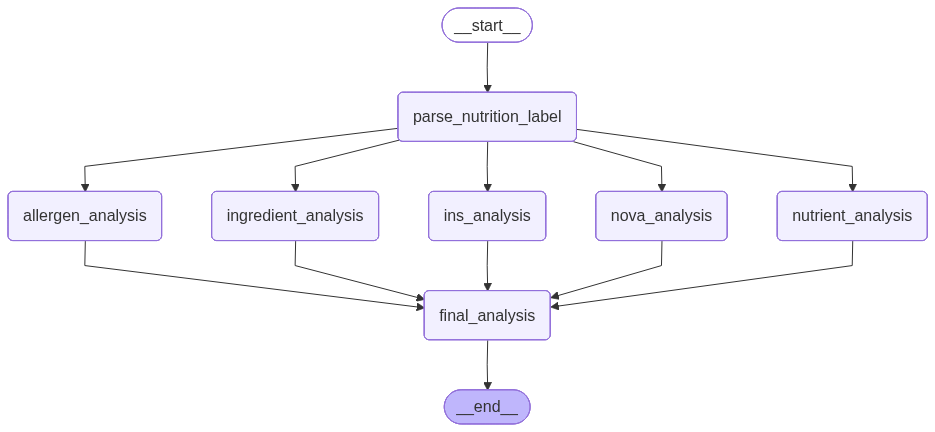

In [46]:
graph = StateGraph(NutritionState)
graph.add_node("parse_nutrition_label", parse_nutrition_label)
graph.add_node("nutrient_analysis", nutrient_analysis)
graph.add_node("ingredient_analysis", ingredient_analysis)
graph.add_node("ins_analysis", ins_analysis)
graph.add_node("allergen_analysis", allergen_analysis)
graph.add_node("nova_analysis", nova_analysis)
graph.add_node("final_analysis", final_analysis)

graph.add_edge(START, "parse_nutrition_label")  
graph.add_edge("parse_nutrition_label", "nutrient_analysis")
graph.add_edge("parse_nutrition_label", "ingredient_analysis")
graph.add_edge("parse_nutrition_label", "ins_analysis")
graph.add_edge("parse_nutrition_label", "allergen_analysis")
graph.add_edge("parse_nutrition_label", "nova_analysis")
graph.add_edge("nutrient_analysis", "final_analysis")
graph.add_edge("ingredient_analysis", "final_analysis")
graph.add_edge("ins_analysis", "final_analysis")
graph.add_edge("allergen_analysis", "final_analysis")
graph.add_edge("nova_analysis", "final_analysis")
graph.add_edge("final_analysis", END)

workflow = graph.compile()
workflow


In [47]:
# Example usage
if __name__ == "__main__":
    input_text = """IngredientsPotato (88%), edible vegetable oil (palmolein), edible common salt, spices & condiments 0.5% (cumin, chilli, parsley, ginger, cinnamon, black pepper, dry mango), dehydrated vegetable powder (onion, garlic), sugar, maltodextrin, flavour enhancer (INS 627, INS 631), acidity regulator (INS 296, INS 330), anticaking agent (INS 551), natural & nature identical flavouring substances (chaat).  Nutritional Information (per 100g)NutrientAmountEnergy545 kcalProtein7.4gCarbohydrates53.5gTotal Sugars3.0gAdded Sugars2.2gTotal Fat32.2gSaturated Fat15.3gTrans Fat0.1gCholesterol<1mgSodium982mg"""
    
    initial_state = {
        "raw_ocr_text": input_text,
        "parsed_label": None,
        "nutrient_analysis": None,
        "ingredient_analysis": None,
        "ins_analysis": None,
        "allergen_analysis": None,
        "processing_analysis": None,
        "final_report": None
    }
    
    result = workflow.invoke(initial_state)
    print("✓ Workflow execution complete!")
    print(f"Final Report: {result.get('final_report', {})}")

✓ Workflow execution complete!
Final Report: {'content': '### 1. Overall Rating: 2.0/5 (Poor)\n**Justification:** While the product starts with a strong whole-food base (88% potato), the remaining 12% consists of ingredients that significantly degrade its nutritional quality. The combination of high saturated fats (palmolein), high sodium (982mg/100g), and a heavy reliance on ultra-processed additives (maltodextrin, flavor enhancers, and nature-identical flavorings) transforms this from a vegetable product into an industrial snack. The high caloric density coupled with a lack of dietary fiber (0g) makes it a low-nutrient, high-calorie food.\n\n### 2. Consumption Recommendation: Occasional\n**Explanation:** Due to the high levels of sodium and saturated fats, this product should be treated as a treat rather than a dietary staple. Frequent consumption could contribute to hypertension and cardiovascular strain. Additionally, the high glycemic index (driven by potatoes, maltodextrin, and s